In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set a nicer font
plt.rcParams['font.family'] = 'sans-serif'
# --- FONT STYLE SETTING ---
# You can change the font family for the labels here.
# For example, to use Times New Roman, you would change the list below to:
# plt.rcParams['font.sans-serif'] = ['Times New Roman', 'DejaVu Sans', 'Verdana']
plt.rcParams['font.sans-serif'] = ['Questrial', 'DejaVu Sans', 'Verdana'] 

# Load the dataset from the CSV file
df = pd.read_csv('final_taxonomy.csv')

# --- Data Preparation ---

# Filter for papers that are included in the review
df_included = df[df['included in review'] == 'Y'].copy()

# Clean up column names by removing leading/trailing whitespace
df_included.columns = df_included.columns.str.strip()

# Clean the 'General Method' and 'Specific Method' columns
# Strip whitespace, and replace empty strings or NaN values with 'Unknown'
for col in ['General Method', 'Specific Method']:
    df_included[col] = df_included[col].str.strip()
    df_included[col].fillna('Unknown', inplace=True)
    df_included.loc[df_included[col] == '', col] = 'Unknown'

/tmp/ipykernel_479572/2920179330.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_included[col].fillna('Unknown', inplace=True)
/tmp/ipykernel_479572/2920179330.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

/tmp/ipykernel_479572/551749246.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  method_by_use_case_df['Use case'].fillna('Other', inplace=True)


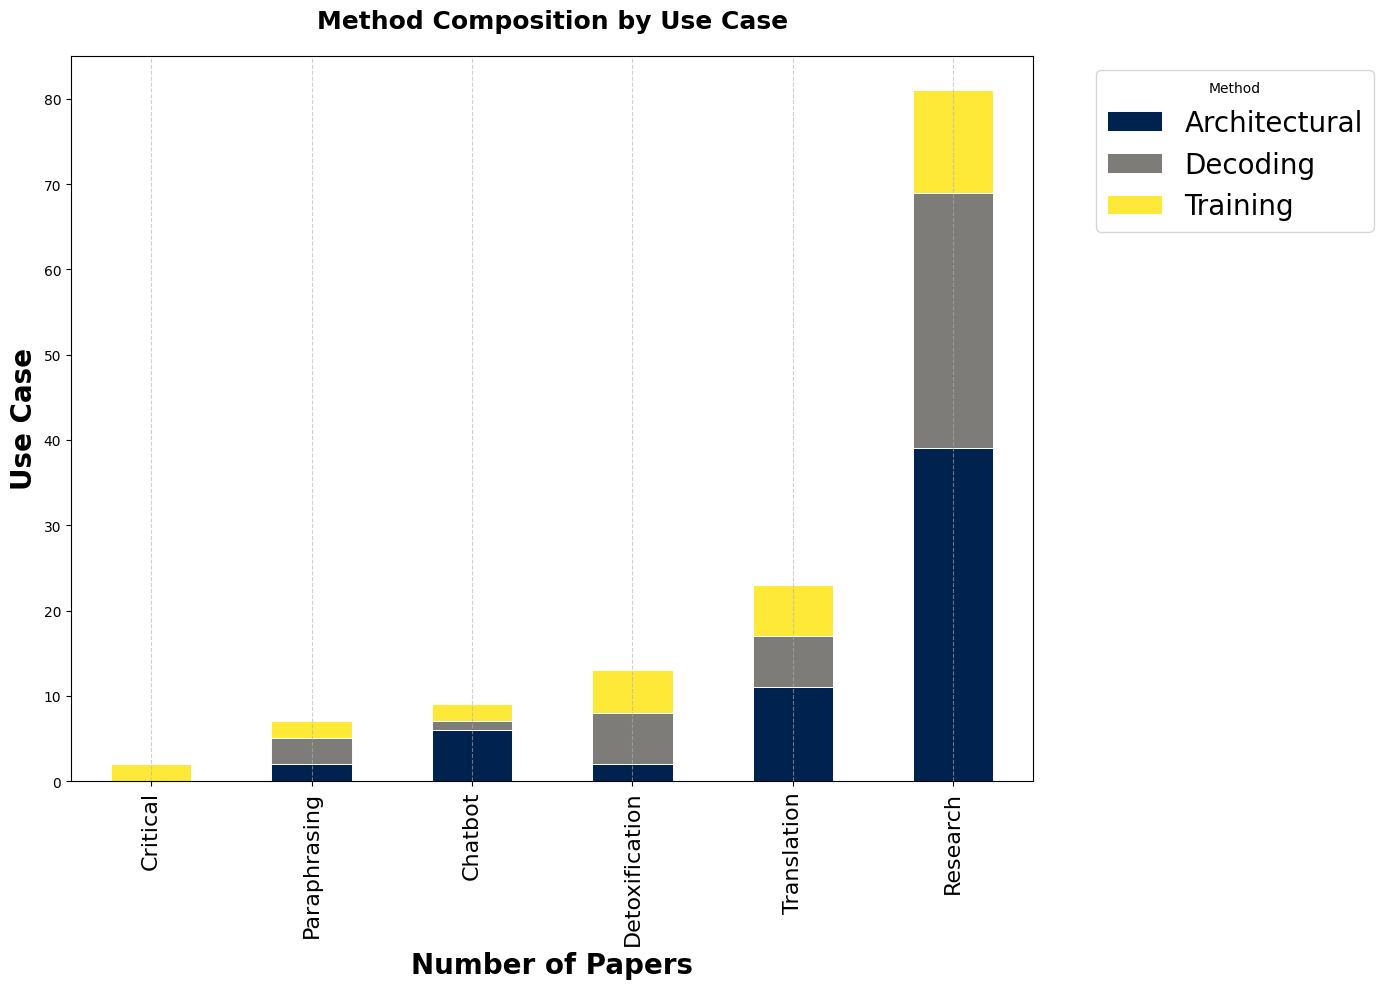

In [2]:
# --- Stacked Bar Chart of General Methods per Use Case ---

# This chart shows the distribution of General Methods for each individual Use Case.
# Each horizontal bar represents a Use Case, and its segments show the
# composition of papers by their General Method.

# --- Data Preparation ---

# 1. Start with a fresh copy of the relevant columns.
method_by_use_case_df = df_included[['Use case', 'General Method']].copy()

# 2. Handle missing/empty 'Use case' data by labeling it as 'Other'.
#    We also filter out papers with an 'Unknown' General Method.
method_by_use_case_df['Use case'].fillna('Other', inplace=True)
method_by_use_case_df.loc[method_by_use_case_df['Use case'] == 'Other', 'Use case'] = 'Research'
method_by_use_case_df = method_by_use_case_df[method_by_use_case_df['General Method'] != 'Unknown']

# 3. Unpack the multi-label 'Use case' column.
#    First, split the strings into lists of words.
method_by_use_case_df['Use case'] = method_by_use_case_df['Use case'].str.split()
#    Then, 'explode' the DataFrame to create a separate row for each use case.
exploded_df = method_by_use_case_df.explode('Use case')

# 4. Create a cross-tabulation to count General Methods per Use Case.
#    This creates a DataFrame perfectly suited for a stacked bar chart.
crosstab_df = pd.crosstab(exploded_df['Use case'], exploded_df['General Method'])

# 5. Sort the data for a cleaner plot.
#    We sort the bars by their total number of papers.
crosstab_df['total'] = crosstab_df.sum(axis=1)
crosstab_df = crosstab_df.sort_values('total', ascending=True).drop(columns='total')

# --- Plotting ---

# Use a colorblind-friendly palette
colors = plt.get_cmap('cividis')(np.linspace(0, 1, len(crosstab_df.columns)))

# Create the stacked horizontal bar chart
ax = crosstab_df.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 10),
    color=colors,
    edgecolor='white',
    linewidth=0.7
)

# --- Formatting the Chart ---

# Add labels and title
ax.set_xlabel('Number of Papers', fontsize=20, weight='bold')
ax.set_ylabel('Use Case', fontsize=20, weight='bold')
ax.set_title('Method Composition by Use Case', fontsize=18, weight='bold', pad=20)

# Customize the legend
ax.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)
ax.tick_params(axis='x', labelsize=16)

# Improve layout
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


/tmp/ipykernel_479572/417939452.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  method_by_use_case_df['Use case'].fillna('Other', inplace=True)


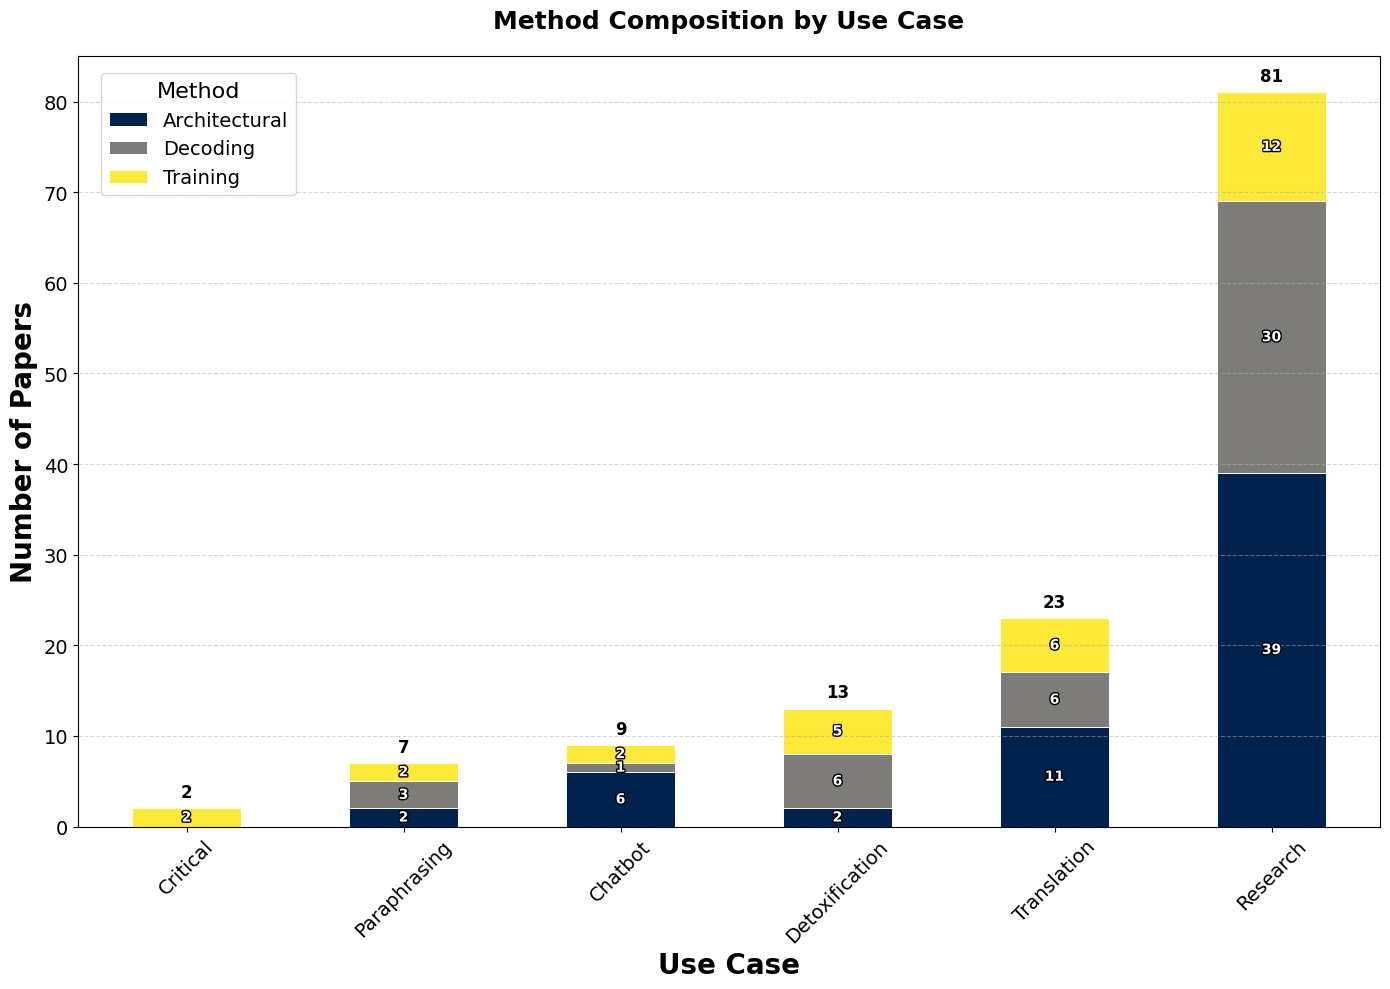

In [11]:
# --- Stacked Bar Chart of General Methods per Use Case (Vertical) ---
# Set a nicer font
plt.rcParams['font.family'] = 'sans-serif'
# --- FONT STYLE SETTING ---
# You can change the font family for the labels here.
# For example, to use Times New Roman, you would change the list below to:
# plt.rcParams['font.sans-serif'] = ['Times New Roman', 'DejaVu Sans', 'Verdana']
plt.rcParams['font.sans-serif'] = ['Questrial', 'DejaVu Sans', 'Verdana'] 

# --- Data Preparation (same as before) ---
method_by_use_case_df = df_included[['Use case', 'General Method']].copy()
method_by_use_case_df['Use case'].fillna('Other', inplace=True)
method_by_use_case_df.loc[method_by_use_case_df['Use case'] == 'Other', 'Use case'] = 'Research'
method_by_use_case_df = method_by_use_case_df[method_by_use_case_df['General Method'] != 'Unknown']
method_by_use_case_df['Use case'] = method_by_use_case_df['Use case'].str.split()
exploded_df = method_by_use_case_df.explode('Use case')

crosstab_df = pd.crosstab(exploded_df['Use case'], exploded_df['General Method'])
crosstab_df['total'] = crosstab_df.sum(axis=1)
crosstab_df = crosstab_df.sort_values('total', ascending=True).drop(columns='total')

# --- Plotting ---
colors = plt.get_cmap('cividis')(np.linspace(0, 1, len(crosstab_df.columns)))

ax = crosstab_df.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 10),
    color=colors,
    edgecolor='white',
    linewidth=0.7
)

# --- Formatting ---
ax.set_xlabel('Use Case', fontsize=20, weight='bold')
ax.set_ylabel('Number of Papers', fontsize=20, weight='bold')
ax.set_title('Method Composition by Use Case', fontsize=18, weight='bold', pad=20)

# Legend inside (top-left)
ax.legend(
    title='Method',
    loc='upper left',
    bbox_to_anchor=(0.01, 0.99),
    fontsize=14,
    title_fontsize=16,
    frameon=True
)

# Remove vertical grid lines (keep horizontal for readability)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.grid(False, axis='x')

import matplotlib.patheffects as path_effects

for container in ax.containers:
    labels = [int(v) if v > 0 else "" for v in container.datavalues]  # hide 0s
    text_labels = ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=10,
        color='white',
        weight='bold'
    )
    # Add a black outline to each text label
    for txt in text_labels:
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='black'),
            path_effects.Normal()
        ])

# --- Add total sum above each bar ---
totals = crosstab_df.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(
        i,                               # x position (bar index)
        total + max(totals)*0.01,        # y position slightly above bar
        f'{total}',                      # text
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='black'
    )

ax.tick_params(axis='x', labelrotation=45, labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig("bar.png")
plt.show()
